In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.get_data import load_data
from src.baseline_models import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.nn_models import fit_poisson_nn
from src.model_utils import summarise_model_results

In [3]:
filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../data/simulated", filenames)

In [4]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

In [5]:
# baseline models
# Linear Baseline (GLM), Non-linear Baseline (XGBoost)
glm_results = fit_poisson_glm(X, Y, cell_ids)
xgboost_results = fit_poisson_xgboost(X, Y, cell_ids)

In [6]:
summarise_model_results(glm_results, model_name="Poisson GLM")


===== Poisson GLM Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4317
Val pseudo-R²:         0.4756
Test pseudo-R²:        0.5133
Train log-likelihood:  11064.39
Val log-likelihood:    2305.71
Test log-likelihood:   3262.24
Train deviance:        6.74
Val deviance:          6.28
Test deviance:         7.38

--- Cell 1.0 ---
Train pseudo-R²:       0.4302
Val pseudo-R²:         0.4729
Test pseudo-R²:        0.5080
Train log-likelihood:  11219.63
Val log-likelihood:    2340.27
Test log-likelihood:   3058.10
Train deviance:        6.86
Val deviance:          6.25
Test deviance:         7.27

--- Cell 2.0 ---
Train pseudo-R²:       0.4337
Val pseudo-R²:         0.4569
Test pseudo-R²:        0.5170
Train log-likelihood:  11270.63
Val log-likelihood:    2277.26
Test log-likelihood:   2837.95
Train deviance:        6.58
Val deviance:          6.48
Test deviance:         6.74

--- Cell 3.0 ---
Train pseudo-R²:       0.4231
Val pseudo-R²:         0.4637
Test pseudo-R²:        0.4991
T

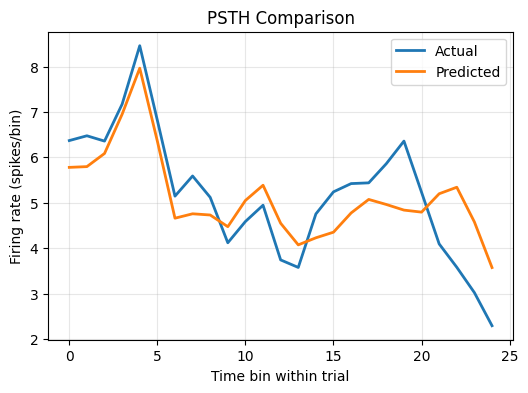

In [7]:
glm_results[0]["test"]["psth_fig"]

In [8]:
summarise_model_results(xgboost_results, model_name="Poisson XGBoost")


===== Poisson XGBoost Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8632
Val pseudo-R²:         0.8126
Test pseudo-R²:        0.7670
Train log-likelihood:  16436.94
Val log-likelihood:    3213.21
Test log-likelihood:   4127.74
Train deviance:        1.62
Val deviance:          2.24
Test deviance:         3.53

--- Cell 1.0 ---
Train pseudo-R²:       0.8604
Val pseudo-R²:         0.7847
Test pseudo-R²:        0.7704
Train log-likelihood:  16661.33
Val log-likelihood:    3172.16
Test log-likelihood:   3930.54
Train deviance:        1.68
Val deviance:          2.55
Test deviance:         3.39

--- Cell 2.0 ---
Train pseudo-R²:       0.8617
Val pseudo-R²:         0.7887
Test pseudo-R²:        0.7674
Train log-likelihood:  16496.34
Val log-likelihood:    3167.74
Test log-likelihood:   3624.52
Train deviance:        1.61
Val deviance:          2.52
Test deviance:         3.25

--- Cell 3.0 ---
Train pseudo-R²:       0.8566
Val pseudo-R²:         0.8052
Test pseudo-R²:        0.76

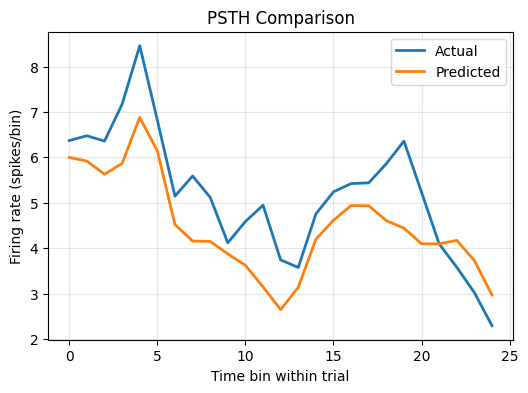

In [9]:
xgboost_results[0]["test"]["psth_fig"]

In [10]:
from sklearn.preprocessing import StandardScaler

nn_results = fit_poisson_nn(
    X, Y, cell_ids, hidden_sizes=[16], lr=1e-3, epochs=500, scaler=StandardScaler
)

In [11]:
summarise_model_results(nn_results, model_name="Poisson Neural Network")


===== Poisson Neural Network Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4136
Val pseudo-R²:         0.4602
Test pseudo-R²:        0.4351
Train log-likelihood:  10839.86
Val log-likelihood:    2264.43
Test log-likelihood:   2995.45
Train deviance:        6.95
Val deviance:          6.46
Test deviance:         8.57

--- Cell 1.0 ---
Train pseudo-R²:       0.4292
Val pseudo-R²:         0.4729
Test pseudo-R²:        0.4659
Train log-likelihood:  11206.54
Val log-likelihood:    2340.11
Test log-likelihood:   2918.24
Train deviance:        6.88
Val deviance:          6.25
Test deviance:         7.89

--- Cell 2.0 ---
Train pseudo-R²:       0.4654
Val pseudo-R²:         0.4800
Test pseudo-R²:        0.5061
Train log-likelihood:  11657.17
Val log-likelihood:    2339.27
Test log-likelihood:   2803.95
Train deviance:        6.22
Val deviance:          6.20
Test deviance:         6.89

--- Cell 3.0 ---
Train pseudo-R²:       0.3382
Val pseudo-R²:         0.3753
Test pseudo-R²:     

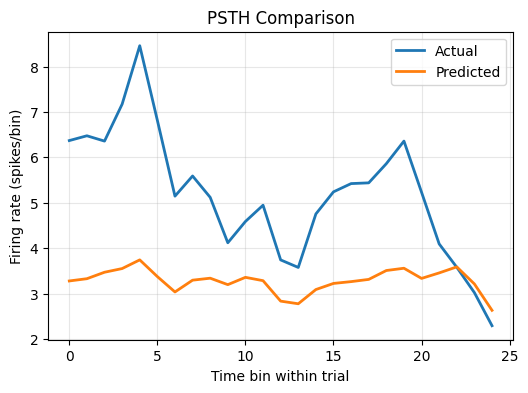

In [12]:
nn_results[0]["test"]["psth_fig"]

In [13]:
cells = sorted(glm_results.keys())

glm_r2 = [glm_results[c]["test"]["pseudo_r2"] for c in cells]
xgb_r2 = [xgboost_results[c]["test"]["pseudo_r2"] for c in cells]
nn_r2 = [nn_results[c]["test"]["pseudo_r2"] for c in cells]

In [14]:
df_test_perf = pd.DataFrame(
    {
        "cell": cells,
        "glm_r2": glm_r2,
        "xgb_r2": xgb_r2,
        "nn_r2": nn_r2,
    }
)

df_test_perf

,cell,glm_r2,xgb_r2,nn_r2
0,0.0,0.513271,0.766979,0.435066
1,1.0,0.507967,0.770435,0.465890
2,2.0,0.516964,0.767374,0.506138
3,3.0,0.499131,0.761546,0.380170
4,4.0,0.503410,0.751916,0.414373
5,10.0,0.410336,0.695806,0.418396
6,11.0,0.428300,0.713880,0.423137
7,12.0,0.468016,0.728732,0.495144
8,13.0,0.448494,0.720874,0.433658
9,14.0,0.425244,0.692670,0.430990


In [15]:
def compare_models_for_cell(glm_results, xgb_results, nn_results, cell, split="test"):
    plt.figure(figsize=(15, 4))

    for i, (results, name) in enumerate(
        [(glm_results, "GLM"), (xgb_results, "XGBoost"), (nn_results, "Neural Network")]
    ):
        y_true = results[cell][f"y_{split}"]
        y_pred = results[cell][f"y_pred_{split}"]

        plt.subplot(1, 3, i + 1)
        plt.scatter(y_true, y_pred, alpha=0.4, s=10)
        plt.plot(
            [y_true.min(), y_true.max()],
            [y_true.min(), y_true.max()],
            "k--",
            linewidth=1,
        )
        plt.title(f"{name} — Cell {cell}")
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

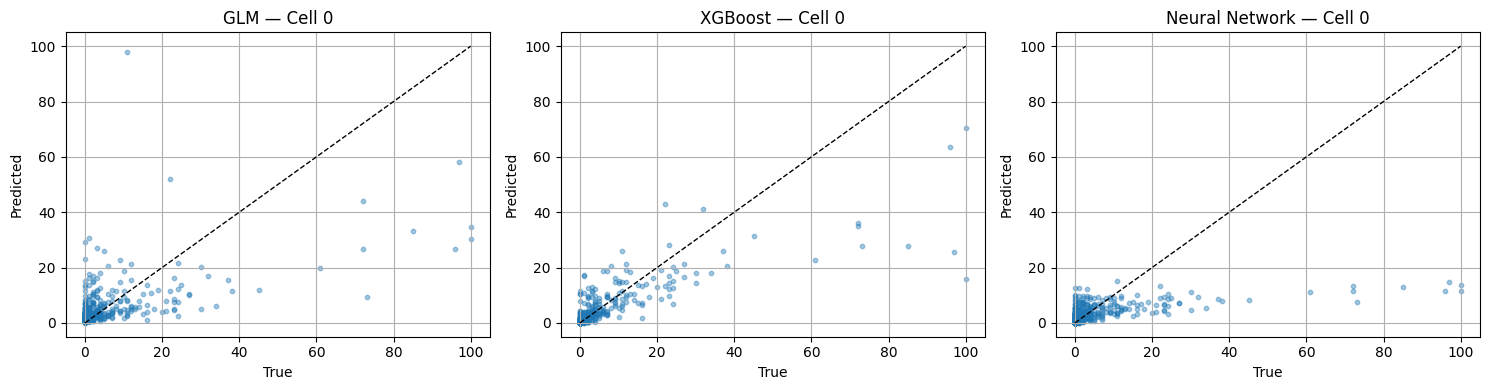

In [16]:
compare_models_for_cell(glm_results, xgboost_results, nn_results, cell=0)

In [21]:
def compare_r2_across_cells(glm_results, xgb_results, nn_results):
    cells = sorted(glm_results.keys())

    glm_r2 = [glm_results[c]["test"]["pseudo_r2"] for c in cells]
    xgb_r2 = [xgb_results[c]["test"]["pseudo_r2"] for c in cells]
    nn_r2 = [nn_results[c]["test"]["pseudo_r2"] for c in cells]

    plt.figure(figsize=(10, 5))
    plt.plot(cells, glm_r2, label="GLM", marker="o")
    plt.plot(cells, xgb_r2, label="XGBoost", marker="o")
    plt.plot(cells, nn_r2, label="Neural Network", marker="o")

    plt.xlabel("Cell ID")
    plt.ylabel("Test pseudo-R²")
    plt.title("Model Performance Across Cells")
    plt.legend()
    plt.grid(True)
    plt.show()

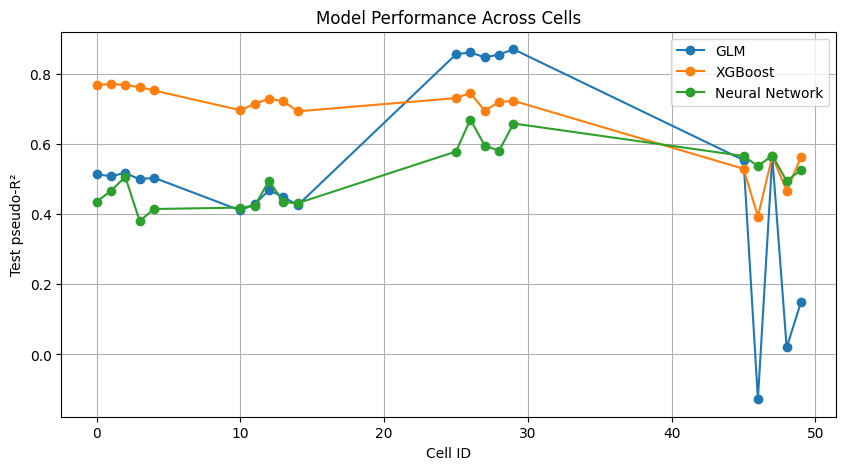

In [22]:
compare_r2_across_cells(glm_results, xgboost_results, nn_results)